In [8]:
import geopandas as gpd
import pypsa
from shapely.geometry import LineString

# Load shapefiles
gdf_buses = gpd.read_file("qgis/buses_aut.shp").to_crs(epsg=4326)
gdf_lines = gpd.read_file("qgis/lines_aut.shp").to_crs(epsg=4326)

# Initialize PyPSA network
n = pypsa.Network()
n.set_snapshots(range(1))  # Minimal snapshot

gdf_buses = gdf_buses.dropna(subset=["geometry"])

# Add buses
for _, row in gdf_buses.iterrows():
    bus_id = str(row["id"]) # switching to name could be more informative: row name
    n.add("Bus",
          name=bus_id,
          x=row.geometry.x,
          y=row.geometry.y,
          v_nom=row.get("v_ref", 380),
          type=row.get("type", "substation"))
    
# Add extra attributes to buses
n.buses["substation_name"] = gdf_buses["name"].values

# Add lines
for _, row in gdf_lines.iterrows():
    line_geom: LineString = row.geometry
    if line_geom is None or line_geom.is_empty or len(line_geom.coords) < 2:
        continue

    bus0 = str(row["from_node"])
    bus1 = str(row["to_node"])
    #if bus0 not in n.buses.index or bus1 not in n.buses.index:
    #    continue

    n.add("Line",
          name=str(row["id"]),
          bus0=bus0,
          bus1=bus1,
          length=row.get("length", line_geom.length), # / 1000,  # meters → km
          r=row.get("r", 0.05),
          x=row.get("x", 0.2),
          c=row.get("c", 0),
          s_nom=row.get("s_max", 100),
          type=row.get("type", None))


In [10]:
gdf_buses

,id,name,v_ref,grid_level,comm,decomm,type,geometry
0,19001.0,Simmering,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.43448 48.18282)
1,39001.0,Simmering,380.0,2.0,2024-01-01,2100-01-01,1.0,POINT (16.43448 48.18282)
2,19002.0,Kaiserebersdorf,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.47564 48.15603)
3,13001.0,Schwechat,110.0,3.0,2024-01-01,2100-01-01,5.0,POINT (16.50701 48.13596)
4,19003.0,Wien Suedost,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.4203 48.12389)
...,...,...,...,...,...,...,...,...
915,14041.0,Sattledt,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (14.05211 48.08325)
916,14043.0,Pyhrn,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (14.33004 47.67829)
917,24141.0,Molln,220.0,2.0,2034-01-01,2100-01-01,1.0,POINT (14.24702 47.90342)
918,14141.0,Molln,30.0,4.0,2034-01-01,2100-01-01,1.0,POINT (14.24702 47.90342)


In [9]:
n.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name
Bus,,,,,,,,,,,,,
19001.0,110.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering
39001.0,380.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering
19002.0,110.0,1.0,16.475635,48.156029,AC,,1.0,0.0,inf,PQ,,,Kaiserebersdorf
13001.0,110.0,5.0,16.507006,48.135957,AC,,1.0,0.0,inf,PQ,,,Schwechat
19003.0,110.0,1.0,16.420303,48.123892,AC,,1.0,0.0,inf,PQ,,,Wien Suedost
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14041.0,110.0,1.0,14.052108,48.083252,AC,,1.0,0.0,inf,PQ,,,Sattledt
14043.0,110.0,1.0,14.330044,47.678294,AC,,1.0,0.0,inf,PQ,,,Pyhrn
24141.0,220.0,1.0,14.247019,47.903419,AC,,1.0,0.0,inf,PQ,,,Molln


In [11]:
gdf_lines

,id,name,active,length,i_max,v_ref,r,x,c,comm,decomm,scenario,from_node,to_node,s_max,type,references,geometry
0,14001.0,182/1,1,5.360,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (13.03562 48.22073, 13.03565 48.219..."
1,14002.0,182/2,1,5.340,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (13.08025 48.25504, 13.07976 48.254..."
2,14003.0,182/7,1,6.220,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14003.0,14001.0,89.547027,None,None,"LINESTRING (13.03666 48.22089, 13.03764 48.220..."
3,14004.0,184/1,1,5.830,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14002.0,89.547027,None,None,"LINESTRING (13.07961 48.2557, 13.07874 48.2552..."
4,11030.0,127-9,1,16.189,470.0,110.0,0.2024,0.4329,6.0483,2024-01-01,2365/01/01,BGL,11002.0,11005.0,89.500000,None,None,"LINESTRING (16.89979 47.84484, 16.89925 47.845..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,20600.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20006.0,90000.0,0.000000,None,None,None
2032,20601.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20003.0,90000.0,0.000000,None,None,None
2033,20602.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20002.0,90000.0,0.000000,None,None,None
2034,31042.0,None,1,0.100,0.0,380.0,0.0000,0.0000,0.0000,2024-01-01,2100/01/01,BGL,31027.0,31020.0,0.000000,None,None,"LINESTRING (16.27613 47.25097, 16.27541 47.25005)"


In [3]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


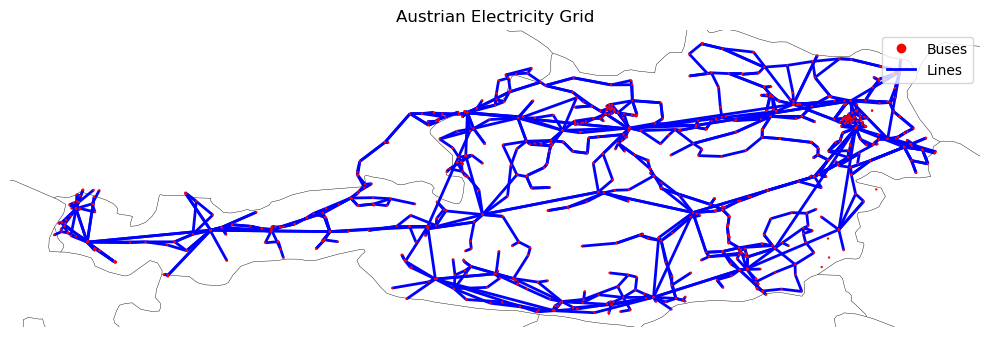

In [4]:
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Plot the network
# Create a figure with GeoAxes using PlateCarree projection (standard lat/lon)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

n.plot(
    ax=ax,
    line_widths=2,
    bus_sizes=.0001,
    line_colors="blue",
    bus_colors="red",
    title="Austrian Electricity Grid",
)

# Add legend manually
legend_elements = [
    plt.Line2D([0], [0], color='red', marker='o', linestyle='None', label='Buses'),
    plt.Line2D([0], [0], color='blue', lw=2, label='Lines'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


## Tag bus country and get cross border lines

In [13]:
import geopandas as gpd

# Load country borders
gdf_countries = gpd.read_file("data/ne_10m_admin_0_sovereignty.shp").to_crs(epsg=4326)

# Ensure bus geometry is in EPSG:4326
gdf_buses = gdf_buses.to_crs(epsg=4326)

# Spatial join to assign each bus to a country
gdf_buses = gpd.sjoin(gdf_buses, gdf_countries[['geometry', 'NAME_EN']], how='left', predicate='within')
gdf_buses.rename(columns={'NAME_EN': 'country'}, inplace=True)


In [18]:
# Step 1: Separate Austrian and non-Austrian buses
at_buses = gdf_buses[gdf_buses["country"] == "Austria"]
non_at_buses = gdf_buses[gdf_buses["country"] != "Austria"]

# Step 2: Create lookup sets
at_bus_set = set(at_buses["id"])
non_at_bus_set = set(non_at_buses["id"])

# Step 3: Identify cross-border lines
cross_border_mask = (
    (gdf_lines["from_node"].isin(at_bus_set) & gdf_lines["to_node"].isin(non_at_bus_set)) |
    (gdf_lines["to_node"].isin(at_bus_set) & gdf_lines["from_node"].isin(non_at_bus_set))
)

gdf_cross_border_lines = gdf_lines[cross_border_mask].copy()

# Optional: Tag all lines
gdf_lines["cross_border"] = cross_border_mask

# Report
print(f"Detected {len(gdf_cross_border_lines)} cross-border lines.")


Detected 55 cross-border lines.


In [22]:
gdf_lines["geometry"].isna

<bound method GeoSeries.isna of 0       LINESTRING (13.03562 48.22073, 13.03565 48.219...
1       LINESTRING (13.08025 48.25504, 13.07976 48.254...
2       LINESTRING (13.03666 48.22089, 13.03764 48.220...
3       LINESTRING (13.07961 48.2557, 13.07874 48.2552...
4       LINESTRING (16.89979 47.84484, 16.89925 47.845...
                              ...                        
2031                                                 None
2032                                                 None
2033                                                 None
2034    LINESTRING (16.27613 47.25097, 16.27541 47.25005)
2035    LINESTRING (16.27613 47.25097, 16.27541 47.25005)
Name: geometry, Length: 2036, dtype: geometry>

<Axes: >

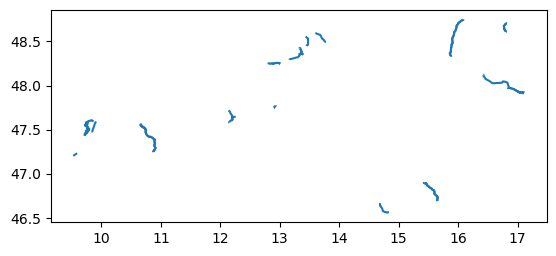

In [7]:
gdf_cross_border_lines.plot()

## Add additional attributes to pypsa network   

In [14]:
n.buses["country"] = gdf_buses["country"].values

In [15]:
n.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name,country
Bus,,,,,,,,,,,,,,
19001.0,110.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
39001.0,380.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
19002.0,110.0,1.0,16.475635,48.156029,AC,,1.0,0.0,inf,PQ,,,Kaiserebersdorf,Austria
13001.0,110.0,5.0,16.507006,48.135957,AC,,1.0,0.0,inf,PQ,,,Schwechat,Austria
19003.0,110.0,1.0,16.420303,48.123892,AC,,1.0,0.0,inf,PQ,,,Wien Suedost,Austria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14041.0,110.0,1.0,14.052108,48.083252,AC,,1.0,0.0,inf,PQ,,,Sattledt,Austria
14043.0,110.0,1.0,14.330044,47.678294,AC,,1.0,0.0,inf,PQ,,,Pyhrn,Austria
24141.0,220.0,1.0,14.247019,47.903419,AC,,1.0,0.0,inf,PQ,,,Molln,Austria


In [20]:
n.lines["cross_border"] = gdf_lines["cross_border"].values

ValueError: Length of values (2036) does not match length of index (1394)

## Mark cross-border lines in pypsa

In [30]:
foreign_buses = n.buses[n.buses["country"] != "Austria"]

In [31]:
foreign_buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name,country
Bus,,,,,,,,,,,,,,
17051.0,110.0,2.0,12.200888,47.641024,AC,,1.0,0.0,inf,PQ,,,Oberaudorf-Ebbs,Germany
17089.0,110.0,3.0,12.372289,48.002385,AC,,1.0,0.0,inf,PQ,,,D-K3,Germany
17090.0,110.0,3.0,12.372304,48.002376,AC,,1.0,0.0,inf,PQ,,,D-K4,Germany
17091.0,110.0,3.0,12.137436,47.718310,AC,,1.0,0.0,inf,PQ,,,D-K2,Germany
17092.0,110.0,3.0,12.137449,47.718320,AC,,1.0,0.0,inf,PQ,,,D-K1,Germany
14116.0,110.0,3.0,12.811583,48.182329,AC,,1.0,0.0,inf,PQ,,,D-K5,Germany
14117.0,110.0,3.0,12.890754,48.217725,AC,,1.0,0.0,inf,PQ,,,D-K6,Germany
14118.0,110.0,3.0,12.794289,48.252434,AC,,1.0,0.0,inf,PQ,,,D-K7,Germany
14119.0,110.0,3.0,13.163605,48.294840,AC,,1.0,0.0,inf,PQ,,,D-K8,Germany


In [32]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000


In [ ]:
cross_border_lines = n.lines[n.lines["bus0"].isin(foreign_buses.index) | n.lines["bus1"].isin(foreign_buses.index)]

In [ ]:
cross_border_lines # better double check that

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c
Line,,,,,,,,,,,,,,,,,,,,,
14013.0,14004.0,14107.0,,0.4031,0.1594,0.0,0.0,93.548064,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18021.0,18010.0,18042.0,,0.4046,0.2049,0.0,0.0,77.543915,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18040.0,18035.0,18025.0,,0.1574,0.1515,0.0,0.0,83.831259,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14009.0,14105.0,14119.0,,0.3980,0.1013,0.0,0.0,131.272131,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14010.0,14119.0,14108.0,,0.3980,0.1013,0.0,0.0,131.272131,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37160.0,37021.0,30009.0,,0.2647,0.0347,0.0,0.0,1574.364902,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37161.0,37021.0,30010.0,,0.2647,0.0347,0.0,0.0,1181.431856,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28059.0,28046.0,20001.0,,0.2808,0.0570,0.0,0.0,457.261413,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
